In [5]:
import numpy as np
def make_grid_reward(n, R_max=0.5):
    c = (n - 1) / 2
    max_dist = 2 * c  # max Manhattan distance
    grid = np.zeros((n, n))

    for x in range(n):
        for y in range(n):
            dist = abs(x - c) + abs(y - c)
            grid[x, y] = R_max * (1 - dist / max_dist)

    return grid

make_grid_reward(10)

array([[0.        , 0.05555556, 0.11111111, 0.16666667, 0.22222222,
        0.22222222, 0.16666667, 0.11111111, 0.05555556, 0.        ],
       [0.05555556, 0.11111111, 0.16666667, 0.22222222, 0.27777778,
        0.27777778, 0.22222222, 0.16666667, 0.11111111, 0.05555556],
       [0.11111111, 0.16666667, 0.22222222, 0.27777778, 0.33333333,
        0.33333333, 0.27777778, 0.22222222, 0.16666667, 0.11111111],
       [0.16666667, 0.22222222, 0.27777778, 0.33333333, 0.38888889,
        0.38888889, 0.33333333, 0.27777778, 0.22222222, 0.16666667],
       [0.22222222, 0.27777778, 0.33333333, 0.38888889, 0.44444444,
        0.44444444, 0.38888889, 0.33333333, 0.27777778, 0.22222222],
       [0.22222222, 0.27777778, 0.33333333, 0.38888889, 0.44444444,
        0.44444444, 0.38888889, 0.33333333, 0.27777778, 0.22222222],
       [0.16666667, 0.22222222, 0.27777778, 0.33333333, 0.38888889,
        0.38888889, 0.33333333, 0.27777778, 0.22222222, 0.16666667],
       [0.11111111, 0.16666667, 0.2222222

In [2]:
with open('player1_weights.txt') as f:
    sections = f.read().split('-----\n')
    for i, s in enumerate(sections):
        print(f"Section {i+1}: {len(s.strip().splitlines())} rows")

Section 1: 8 rows
Section 2: 256 rows
Section 3: 256 rows


In [ ]:
K = env.K
net = QNet(state_dim=8, K=K, hidden=256)
for name, p in net.named_parameters():
    print(name, p.shape)

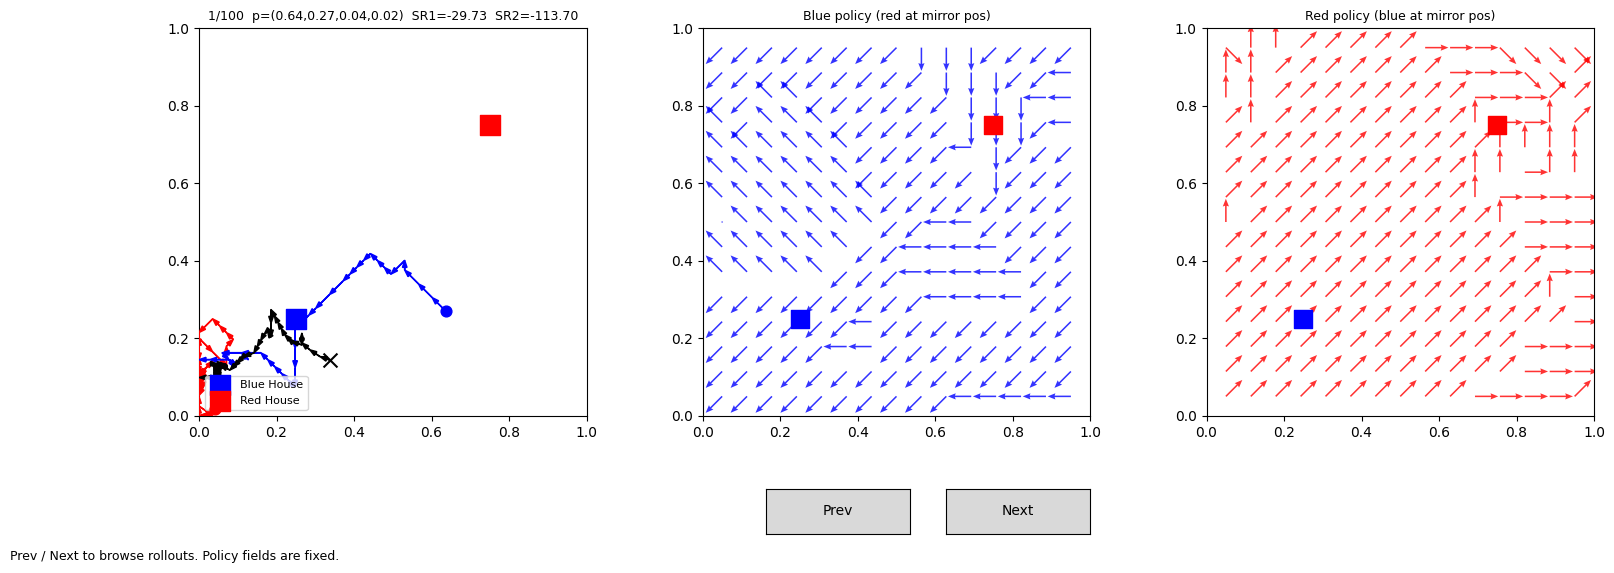

In [5]:
import dog_planning_dqn as dqn
import importlib
importlib.reload(dqn)
import torch

env = dqn.DogGame(step=dqn.STEP, K_dirs=dqn.NUM_ACTIONS, add_stay=True,
                  house_r=0.03, max_episode_steps=dqn.STEPS_PER_EPISODE,
                  seed=0, houses_fixed=(0.25, 0.25, 0.75, 0.75))
device = "cuda" if torch.cuda.is_available() else "cpu"
K = env.K
net1 = dqn.QNet(state_dim=8, K=K, hidden=256).to(device)
net2 = dqn.QNet(state_dim=8, K=K, hidden=256).to(device)
dqn.load_weights_txt(net1, 'player1_weights.txt')
dqn.load_weights_txt(net2, 'player2_weights.txt')
dqn.browse(env, net1, net2, N=100, T=120, seed=0, device=device)